### Week 9 — Model Optimization

#### Task
Improve model performance using:
- Hyperparameter TuniTg
- GridearchCV

### Deliverables

#### Model Performance Comparison
| Model | Before | After |
|---------|---------|---------|
| Model Name | Performance Score | Improved Score |

### Improvements
- Tuned model hyperparameters to achieve better performance.
- Used **GridSearchCV** to find the best parameter combination.
- Improved model accuracy and overall prediction quality.

## Skills Tested
- Model Optimization
- Hyperparameter Tuning
- GridSearchCV

### 1. Importing Libraries:


In [1]:
import pandas as pd
import numpy as np
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
STOPWORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

### 2. Loading The Dataset:

In [2]:
df = pd.read_csv("tickets.csv")
df.head()

,text,category
0,Upload keeps getting stuck at 90 percent,Upload issue
1,Incorrect username or password error,Login issue
2,Upload fails with server error 500,Upload issue
3,Settings not saving after change,Bug report
4,Permission error when opening file,Permission issue


In [3]:
df['category'].value_counts()

category
Upload issue         25
Login issue          25
Bug report           25
Permission issue     25
Payment issue        25
Network issue        25
Feature request      25
Performance issue    25
Name: count, dtype: int64

### 3.Text Preprocessing:

In [4]:
def clean_text(text: str) -> str:
    # Lowercase, strip non-letters, remove stopwords, lemmatize (as verbs)
    text = re.sub('[^a-zA-Z]', ' ', text)
    text = text.lower()
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w, pos='v') for w in tokens if w not in STOPWORDS]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(clean_text)
df[['text', 'clean_text', 'category']].head(8)

,text,clean_text,category
0,Upload keeps getting stuck at 90 percent,upload keep get stick percent,Upload issue
1,Incorrect username or password error,incorrect username password error,Login issue
2,Upload fails with server error 500,upload fail server error,Upload issue
3,Settings not saving after change,settings save change,Bug report
4,Permission error when opening file,permission error open file,Permission issue
5,Unable to complete payment transaction,unable complete payment transaction,Payment issue
6,Payment method expired needs update,payment method expire need update,Payment issue
7,Form validation not working correctly,form validation work correctly,Bug report


### 4. TF-IDF Vectorization:

In [5]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['clean_text'])
y = df['category']

print('Feature matrix shape:',X.shape)
print('Vocabulary size:',len(vectorizer.vocabulary_))

Feature matrix shape: (200, 352)
Vocabulary size: 352


### 5. Train/Test Split:

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42,stratify=y)
print('Train Data Size:',X_train.shape[0])
print('Test Data Size:',X_test.shape[0])

Train Data Size: 160
Test Data Size: 40


### 6.Train The Model:

In [9]:
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

baseline_accuracy = accuracy_score(y_test, lr_pred)
print('Logistic Regression Accuracy (default hyperparameters):', baseline_accuracy)
print()
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy (default hyperparameters): 0.825

                   precision    recall  f1-score   support

       Bug report       1.00      0.40      0.57         5
  Feature request       1.00      0.80      0.89         5
      Login issue       1.00      0.80      0.89         5
    Network issue       0.80      0.80      0.80         5
    Payment issue       0.83      1.00      0.91         5
Performance issue       0.56      1.00      0.71         5
 Permission issue       0.83      1.00      0.91         5
     Upload issue       1.00      0.80      0.89         5

         accuracy                           0.82        40
        macro avg       0.88      0.82      0.82        40
     weighted avg       0.88      0.82      0.82        40



### 7.Model Optimization using GridSearchCV:

In [8]:
# Define hyperparameters to tune
from sklearn.model_selection import GridSearchCV


param_grid = {
    'C': [0.01, 0.1, 1, 10, 50, 100],
    'solver': ['lbfgs', 'newton-cg'],
    'max_iter': [100, 200]
}

# Create GridSearchCV
grid_search = GridSearchCV(LogisticRegression(), param_grid, cv=5, scoring='accuracy')

# Fit the model
grid_search.fit(X_train, y_train)

# Get best parameters and score
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# Evaluate on test set
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
print(f"Test accuracy with tuned model: {tuned_accuracy:.4f}")
print(classification_report(y_test, y_pred_tuned))

Best parameters: {'C': 50, 'max_iter': 100, 'solver': 'lbfgs'}
Best cross-validation score: 0.8187
Test accuracy with tuned model: 0.8000
                   precision    recall  f1-score   support

       Bug report       1.00      0.20      0.33         5
  Feature request       1.00      0.80      0.89         5
      Login issue       0.80      0.80      0.80         5
    Network issue       0.80      0.80      0.80         5
    Payment issue       0.83      1.00      0.91         5
Performance issue       0.56      1.00      0.71         5
 Permission issue       0.83      1.00      0.91         5
     Upload issue       1.00      0.80      0.89         5

         accuracy                           0.80        40
        macro avg       0.85      0.80      0.78        40
     weighted avg       0.85      0.80      0.78        40



### 8. Before vs After Comparison:

In [10]:
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression'],
    'Before (default params)': [round(baseline_accuracy, 3)],
    'After (GridSearchCV tuned)': [round(tuned_accuracy, 3)],
    'Improvement': [round(tuned_accuracy - baseline_accuracy, 3)]
})
comparison_df

,Model,Before (default params),After (GridSearchCV tuned),Improvement
0,Logistic Regression,0.825,0.8,-0.025


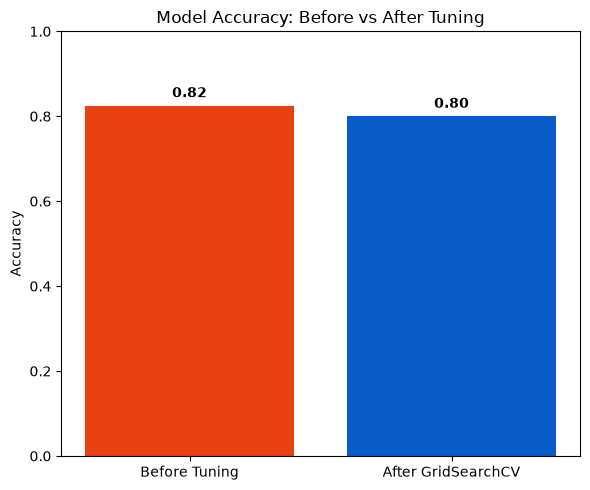

In [11]:
fig, ax = plt.subplots(figsize=(6, 5))

# Accuracy comparison bar chart
ax.bar(
    ['Before Tuning', 'After GridSearchCV'],
    [baseline_accuracy, tuned_accuracy],
    color=["#e94113", "#095bc7"]
)

ax.set_ylim(0, 1)
ax.set_ylabel('Accuracy')
ax.set_title('Model Accuracy: Before vs After Tuning')

for i, v in enumerate([baseline_accuracy, tuned_accuracy]):
    ax.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()